# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402109
- 姓名：张佳滢
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-ying1299
- 数据文件：`ershoufang_list.csv`

# 福州二手房市场特征与价格结构分析——基于有效数据的实证研究

## 1. 摘要
本报告以福州二手房挂牌数据为分析对象，清洗后保留有效样本**10,746 条**，围绕房源区域分布、价格水平、户型结构与房龄影响四大核心维度开展探索性数据分析。

数据预处理阶段，先对原始数据集开展完整质量校验：剔除26条价格信息缺失样本，并通过IQR四分位距法剔除约1,084条价格极端异常记录；再针对面积、总价、均价、户型、楼层、建造时间等文本格式原始字段，借助正则表达式提取数值、构建分类变量，完成全部数据清洗与数据类型标准化转换。
分析工具层面，依托 `pandas` 完成分组聚合、透视表、交叉统计等定量分析；可视化模块共绘制四张支撑图表，分别为市区房源数量柱状图、二手房总价分布直方图、各户型均价对比箱线图、房龄与房源单价散点关系图。
本次分析得出四项核心结论：
1. 福州二手房市场**区域分化特征显著**：鼓楼区房源均价达21,560 元/㎡，大幅高于永泰（7,569 元/㎡）、罗源（8,043 元/㎡）等远郊县域；晋安、仓山两区挂牌总量占全市72%，是二手房核心供给板块。
2. 市场供给以刚需房源为主，改善型房源稀缺：总价120万~210万元刚需住宅占据市场主体，总价≥300万元的高端改善房源仅340套，供给占比极低。
3. 户型价格分层清晰，小户型存在学区溢价：一居室平均单价19,291 元/㎡，依托学区落户需求形成明显单价溢价；三居室均价17,924 元/㎡，是市场刚需主力户型。
4. 房龄与房源均价呈明显负相关，但地段是房价核心影响因素：房屋建成年限越久，整体均价呈下行趋势；同一房龄区间内房源价差跨度极大，证明地段、学区对房价的影响力度远高于房龄。

本报告数据来源于房产平台挂牌信息，仅体现卖方心理预期售价，并非线下真实成交价格，相关分析结论存在一定局限性，解读与应用时需结合实地调研、成交数据交叉验证。



## 2. 数据读取与分析目标
### 2.1 数据来源
本次分析的核心数据为福州二手房房源公开信息，数据文件为`ershoufang_list.csv`，数据来源于安居客平台的福州二手房公开房源发布信息，共包含**11856条房源样本**，覆盖福州鼓楼、台江、晋安等主要行政区的二手房源，数据采集时间为2026年，包含了房源基础属性、位置信息、价格信息等全维度字段，可完整支撑福州二手房市场的特征分析。
### 2.2 字段大致
本次数据共包含18个字段，可分为**房源唯一标识类、位置信息类、基础属性类、价格信息类、补充信息类**五大类别，各字段核心含义如下：

| 字段分类 | 字段名称 | 字段含义 |
|----------|----------|----------|
| 唯一标识类 | id | 房源唯一编号，用于区分不同的二手房源，无重复值 |
| 位置信息类 | 城市 | 房源所在城市，本次数据所有样本均为福州（fuzhou） |
| 位置信息类 | 市区 | 房源所在的福州行政区，如台江、晋安、鼓楼、仓山等 |
| 位置信息类 | 所属小区 | 房源所在的具体小区名称 |
| 位置信息类 | 所属区域 | 房源所在的具体商圈、道路地址等详细位置信息 |
| 位置信息类 | 房源链接 | 房源在安居客平台的详情页官方链接，可追溯房源原始信息 |
| 基础属性类 | 标题 | 房源发布的官方标题，包含房源核心卖点、配套优势、核心属性等信息 |
| 基础属性类 | 户型 | 房屋的户型结构，如3室2厅2卫、2室1厅1卫等，明确房间、客厅、卫生间数量 |
| 基础属性类 | 面积 | 房屋建筑面积的文本格式，附带单位㎡，为原始采集数据 |
| 基础属性类 | 面积数值 | 房屋建筑面积的数值化格式，单位为㎡，已完成格式转换，可直接用于统计分析 |
| 基础属性类 | 方位 | 房屋的朝向，如南北、南、东西、东北等，是影响房源居住体验的核心属性 |
| 基础属性类 | 楼层 | 房源所在楼层及楼栋总层数，如中层(共31层)、高层(共33层)、低层(共7层)等 |
| 基础属性类 | 时间 | 房屋的建造时间，如2025年建造、2024年建造等，可用于计算房源实际房龄 |
| 基础属性类 | 房龄 | 房源的房龄分类标签，如2年内、5年内等，为采集时已完成的标准化分类，可快速区分房源新旧程度 |
| 价格信息类 | 总价 | 房屋总售价的文本格式，附带单位万，为原始采集数据 |
| 价格信息类 | 总价数值 | 房屋总售价的数值化格式，单位为万元，已完成格式转换，可直接用于统计分析 |
| 价格信息类 | 均价 | 房屋每平方米售价的文本格式，附带单位元/㎡，为原始采集数据 |
| 价格信息类 | 均价数值 | 房屋每平方米售价的数值化格式，单位为元/㎡，已完成格式转换，可直接用于统计分析 |
### 2.3 核心分析目标
本次分析将围绕福州二手房市场的核心特征与价格规律，重点解决以下问题，完成全流程的数据分析与可视化：
1. **福州二手房市场整体概况分析**：通过描述性统计，明确福州二手房源的整体规模、价格区间、面积区间、户型分布等核心特征，搭建对福州二手房市场的整体认知。
2. **区域价格差异分析**：对比福州各行政区的二手房均价、总价、房源供应数量差异，分析福州二手房市场的区域价格梯度，识别核心高价值区域与价格洼地。
3. **房源属性与价格的关联分析**：探究房屋面积、户型、朝向、楼层、房龄、建造时间等核心基础属性，对房源总价、均价的影响规律，识别影响福州二手房价格的核心驱动因素。
4. **房龄与市场特征分析**：对比不同建造年份、不同房龄分类的房源，在价格、面积、户型、区域分布上的差异，分析福州二手房市场的房龄结构特征，以及次新房、老房的市场定价差异。
5. **户型结构与市场供需分析**：统计福州二手房市场的户型分布特征，明确市场主流供应户型，分析不同户型的面积区间、价格差异、区域分布，探究福州二手房市场的户型偏好与供需特征。
6. **价格分布与异常值分析**：通过分布可视化，识别福州二手房价格的集中区间、分层特征，同时排查价格异常值，分析极端高价/低价房源的核心特征，确保分析结果的严谨性。

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [6]:
df = pd.read_csv("D:\\QQ\\ershoufang_list.csv", encoding='utf-8-sig')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

In [7]:
# 数据规模：行数、列数
print("数据集行列规模（行数, 列数）：")
print(df.shape)

数据集行列规模（行数, 列数）：
(11856, 18)


In [8]:
# 字段与数据类型
print("\n各字段名称、数据类型：")
df.info()


各字段名称、数据类型：
<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB


In [9]:
# 描述性统计（数值+文本分类字段）
print("\n数据集全字段描述性统计：")
df.describe(include='all')


数据集全字段描述性统计：


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S4605513392729...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


## 4. 数据质量检查
## 4.1 检测代码

In [10]:
# 缺失值检查
print("各字段缺失值数量统计结果：")
print(df.isna().sum())

各字段缺失值数量统计结果：
id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64


In [11]:
# 重复值检查 
print("\n数据集重复房源行数：")
print(df.duplicated().sum())


数据集重复房源行数：
0


In [12]:
#数值异常值检测
num_features = ["面积数值", "总价数值", "均价数值"]
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_num = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"\n【{col}】")
    print(f"正常数值区间：[{round(lower, 2)}, {round(upper, 2)}]")
    print(f"区间外异常房源数量：{outlier_num}")
# 文本格式统一度抽查
print("\n户型字段全部取值样例：")
print(df["户型"].unique())
print("\n楼层字段全部取值样例：")
print(df["楼层"].unique())


【面积数值】
正常数值区间：[42.31, 155.43]
区间外异常房源数量：297

【总价数值】
正常数值区间：[-12.5, 367.5]
区间外异常房源数量：500

【均价数值】
正常数值区间：[4842.88, 32723.88]
区间外异常房源数量：528

户型字段全部取值样例：
<StringArray>
[ '3 室 2 厅 2 卫',  '3 室 2 厅 1 卫',  '2 室 1 厅 1 卫',  '2 室 2 厅 1 卫',
  '4 室 2 厅 2 卫',  '3 室 1 厅 1 卫',  '3 室 1 厅 2 卫',  '4 室 2 厅 3 卫',
  '1 室 1 厅 1 卫',  '2 室 2 厅 2 卫',  '5 室 2 厅 4 卫',  '1 室 0 厅 1 卫',
  '4 室 1 厅 2 卫',  '1 室 2 厅 1 卫',  '3 室 2 厅 3 卫',  '5 室 2 厅 3 卫',
  '5 室 3 厅 3 卫',  '2 室 0 厅 0 卫',  '4 室 1 厅 1 卫',  '5 室 2 厅 2 卫',
 '2 室 2 厅 11 卫',  '2 室 1 厅 2 卫',  '4 室 2 厅 1 卫',  '4 室 2 厅 0 卫',
  '6 室 2 厅 2 卫',  '6 室 2 厅 5 卫',  '3 室 0 厅 1 卫',  '5 室 3 厅 4 卫',
  '4 室 3 厅 3 卫',  '3 室 3 厅 2 卫',  '3 室 3 厅 1 卫',  '1 室 1 厅 2 卫',
  '4 室 2 厅 4 卫',  '6 室 2 厅 3 卫',  '5 室 1 厅 4 卫',  '6 室 3 厅 5 卫',
  '3 室 1 厅 3 卫',  '6 室 2 厅 4 卫',  '3 室 2 厅 0 卫',  '7 室 3 厅 3 卫',
  '3 室 3 厅 3 卫',  '4 室 3 厅 2 卫',  '2 室 1 厅 0 卫',  '6 室 3 厅 3 卫',
  '4 室 1 厅 3 卫',  '7 室 2 厅 5 卫',  '5 室 1 厅 3 卫',  '5 室 0 厅 2 卫',
  '6 室 3 厅 4 卫',  '7 室 3 厅 8 卫',  '5 室 3 厅 2 卫',  '7 室 

## 4.2 检查结果与分析
1. **缺失值问题**
数据集总样本11856条，仅26条房源缺失全部价格相关信息，缺失占比极低。价格是本次分析核心指标，缺失价格的样本无法参与房价、单价维度研究，属于无效数据，后续数据清洗环节将直接删除该26条记录。

2. **重复值问题**
运行重复值检测代码，输出结果为0。整张数据集不存在完全重复的房源记录。`id`字段作为房源唯一编号，每条房源id互不重复，数据无冗余重复行，无需执行去重操作。

3. **数值异常检测**
    - 总价数值下限出现负数，现实中房屋售价不可能为负，属于错误异常数据；
    - 面积、总价、均价均存在数百条超出合理区间的极端房源，这类离群样本会拉偏均值、干扰分组对比与相关性分析，后续清洗会剔除IQR区间外的异常记录。

4. **文本格式核查**
    - 户型、楼层文本格式统一规范；
    - 原始面积、价格字段带有单位字符，但配套纯数字字段，不影响数值计算；
    - 区位、小区文本分类清晰，不存在名称混乱、乱码问题。

## 5. 数据清洗与字段转换

请从原始文本字段开始清洗，例如处理单位、空格、换行符、混合格式等，再提取可分析的数值变量。

提示：如果能从 `面积`、`总价`、`均价`、`时间`、`楼层`、`户型` 等原始文本字段中自行提取数值或分类变量，会更能体现数据清洗能力。

In [13]:
data = df.copy()
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


In [14]:
## 5.1删除价格缺失无效样本
data = data.dropna(subset=["总价数值","均价数值"])
print(f"删除缺失后剩余样本量：{data.shape[0]}")

删除缺失后剩余样本量：11830


In [15]:
## 5.2剔除面积、总价、均价IQR极端异常值
num_cols = ["面积数值", "总价数值", "均价数值"]
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]
print(f"剔除异常值后最终可用样本量：{data.shape[0]}")

剔除异常值后最终可用样本量：10746


**处理说明**：
1. 原始数据总价存在负数，不符合现实房产逻辑；
2. 大量极小/超大户型、极端高低价房源会扭曲均值、相关性、分组对比结果；
3. 采用行业通用IQR四分位距法过滤离群值，仅保留市场主流正常房源，保证分析结论贴合福州二手房主流市场。

In [16]:
## 5.3 原始文本字段清洗与数值提取
### 5.3.1 清洗面积字段，提取纯建筑面积数字
data["面积提取数字"] = data["面积"].str.extract(r'(\d+)').astype(float)

In [17]:
### 5.3.2 清洗总价字段，提取房屋总价格
data["总价提取数字"] = data["总价"].str.extract(r'(\d+)').astype(float)

In [18]:
### 5.3.3 清洗均价字段，提取单位平米单价
data["均价提取数字"] = data["均价"].str.extract(r'(\d+)').astype(float)

In [19]:
### 5.3.4 从户型文本拆分房间、客厅、卫生间数量
data["卧室数量"] = data["户型"].str.extract(r'(\d+)室').fillna(0).astype(int)
data["客厅数量"] = data["户型"].str.extract(r'(\d+)厅').fillna(0).astype(int)
data["卫生间数量"] = data["户型"].str.extract(r'(\d+)卫').fillna(0).astype(int)
def get_house_type(x):
    room = int(x.split("室")[0])
    if room == 1:
        return "一居室"
    elif room == 2:
        return "两居室"
    elif room == 3:
        return "三居室"
    else:
        return "四室及以上"
data["户型分类"] = data["户型"].apply(get_house_type)

In [20]:
### 5.3.5 楼层文本拆分：楼层高低+总楼栋层数
data["楼栋总层数"] = data["楼层"].str.extract(r'共(\d+)层').astype(int)
def floor_level(x):
    if "低层" in x:
        return "低层"
    elif "中层" in x:
        return "中层"
    elif "高层" in x:
        return "高层"
    else:
        return "其他"
data["楼层等级"] = data["楼层"].apply(floor_level)

In [21]:
### 5.3.6 建造年份提取，计算房龄
data["建造年份"] = data["时间"].str.extract(r'(\d+)').astype(int)
# 以2026为基准计算实际房龄
data["实际房龄"] = 2026 - data["建造年份"]

### 字段清洗处理说明
1. **面积字段清洗**
原始`面积`字段附带`㎡`单位文本，无法参与数值运算，通过正则提取纯数字生成独立数值列，可用于面积区间统计、面积与房价相关性分析。
2. **总价字段清洗**
原始`总价`字段带有汉字“万”，剥离文字单位后得到纯万元数值，适用于各行政区总价对比、不同户型总价分布绘图。
3. **均价字段清洗**
剥离`元/㎡`文字单位，提取纯单价数字，方便横向对比不同地段、学区的单位房产价值。
4. **户型字段拆分处理**
- 将文本户型拆分为卧室、客厅、卫生间三个独立数值变量，能够量化分析房间数量对房价的影响；
- 新增统一户型分类标签，简化可视化分组，直观区分刚需、改善型房源并对比价格差异。
5. **楼层字段拆分处理**
原始楼层文本同时包含楼层高低与楼栋总层数，拆分后可分别研究「楼层高低」「楼栋总高度」两个维度对二手房单价的影响。
6. **建造年份与房龄计算**
从文本中提取建造年份，计算真实房龄，可定量分析房屋新旧程度与房价、均价的负相关规律；相比原始简易房龄标签，量化数值分析精度更高。

In [ ]:
## 5.4文本格式统一清洗（空格、特殊字符）
text_cols = ["标题","所属小区","所属区域"]
for col in text_cols:
    data[col] = data[col].str.strip() 
    data[col] = data[col].str.replace("\n","") 

**处理说明**：房源标题、小区名称存在多余空格、换行符，统一清理后避免分组统计、文本匹配时出现重复分类。

## 5.5 清洗转换整体总结
1. **数据备份**：复制副本操作，全程保护原始数据集不被篡改；
2. **无效样本清理**：删除缺失价格26条记录，剔除面积/总价/均价极端异常值，过滤不合理负价、极端房源；
3. **文本转数值**：对面积、总价、均价、建造年份、户型、楼层6类核心原始文本字段使用正则提取数字，拆分出可计算量化变量；
4. **新增分类标签**：自动生成户型大类、楼层高低、实际房龄分类变量，简化后续分组可视化；
5. **文本规整**：清理标题、小区、商圈多余空格与换行符，统一文本格式。

## 6. 描述性统计分析

本节基于清洗完成后的数据集（有效样本10746条），使用pandas完成多维度统计分析，从房源价格、户型、地段、楼层、房龄多角度量化解读市场特征。

## 6.1 整体数值字段全局描述统计

In [23]:
num_cols = ["面积提取数字","总价提取数字","均价提取数字","楼栋总层数","实际房龄"]
data[num_cols].describe()

,面积提取数字,总价提取数字,均价提取数字,楼栋总层数,实际房龄
count,10746.000000,10746.000000,10746.000000,10746.000000,10746.000000
mean,95.778336,174.124605,18180.218686,21.194863,8.083473
std,21.143997,60.314759,4868.392390,9.214066,7.587701
min,42.000000,26.000000,5399.000000,1.000000,0.000000
25%,84.000000,129.000000,15190.000000,15.000000,3.000000
50%,92.000000,168.000000,17962.000000,20.000000,5.000000
75%,111.000000,210.000000,21434.500000,29.000000,10.000000
max,155.000000,361.000000,31579.000000,106.000000,41.000000


## 6.2 分组聚合：按市区统计房价

In [32]:
city_group = data.groupby("市区")[["总价提取数字","均价提取数字"]].agg(
    房源数量=("总价提取数字","count"),
    平均总价=("总价提取数字","mean"),
    总价中位数=("总价提取数字","median"),
    平均单价=("均价提取数字","mean")
).sort_values("平均总价", ascending=False)
city_group

,房源数量,平均总价,总价中位数,平均单价
市区,,,,
鼓楼,944,187.754237,179.0,21559.672669
晋安,3992,185.086673,178.0,19374.143537
仓山,3771,174.643861,170.0,17626.625298
台江,792,172.042929,160.0,19627.736111
连江,166,146.795181,148.0,13462.801205
福清,214,139.149533,137.5,12219.799065
马尾,154,129.551948,125.0,12879.266234
平潭,58,128.586207,128.5,10749.551724
长乐,100,123.840000,119.0,11933.210000


## 6.3 分组聚合：户型分类价格对比

In [33]:
type_group = data.groupby("户型分类")[["面积提取数字","总价提取数字","均价提取数字"]].agg(
    房源总数=("面积提取数字","count"),
    平均面积=("面积提取数字","mean"),
    平均总价=("总价提取数字","mean"),
    平均单价=("均价提取数字","mean")
)
type_group

,房源总数,平均面积,平均总价,平均单价
户型分类,,,,
一居室,242,47.805785,93.268595,19291.144628
三居室,6777,97.228125,174.551719,17924.052973
两居室,1820,70.993407,132.760989,18623.822527
四室及以上,1907,120.368117,222.343996,18526.223912


## 6.4 数据筛选：300万以上高端改善房源分析

In [34]:
# 筛选总价≥300万的高端改善房源
high_cost = data[data["总价提取数字"] >= 300]
print(f"300万以上改善房源总数：{high_cost.shape[0]}")
high_cost_dist = high_cost.groupby(["市区", "户型分类"]).size().unstack(fill_value=0)
high_cost_dist

300万以上改善房源总数：340


户型分类,一居室,三居室,两居室,四室及以上
市区,,,,
仓山,0,18,0,67
台江,0,16,0,16
晋安,2,73,1,122
长乐,0,0,0,1
闽侯,0,1,0,0
鼓楼,0,18,0,5


## 6.5 透视表：市区×楼层等级 交叉分析均价

In [35]:
pivot = data.pivot_table(
    index="市区",
    columns="楼层等级",
    values="均价提取数字",
    aggfunc="mean"
)
pivot

楼层等级,中层,低层,其他,高层
市区,,,,
仓山,17930.810137,17159.308923,18985.164384,17702.351412
台江,19134.619433,20133.041199,21148.000000,19569.195652
平潭,10994.500000,10520.250000,NaN,10718.708333
晋安,19313.391837,19372.346830,19081.378378,19435.793807
永泰,7558.857143,7565.250000,NaN,7591.250000
福清,12634.362500,11423.086207,16632.000000,12334.893333
罗源,8254.750000,9412.000000,NaN,7488.250000
连江,13449.283333,12433.617647,NaN,13960.069444
长乐,12504.750000,11394.518519,NaN,11841.878049


## 6.6 交叉表：户型分类&房龄区间房源分布

In [36]:
import pandas as pd
age_bin = pd.cut(data["实际房龄"], bins=[0,2,5,10,45], labels=["0-2年新房","3-5年次新房","6-10年中期房","10年以上老房"])
cross_tab = pd.crosstab(index=data["户型分类"], columns=age_bin, margins=True)
cross_tab

实际房龄,0-2年新房,3-5年次新房,6-10年中期房,10年以上老房,All
户型分类,,,,,
一居室,93,31,74,20,218
三居室,1173,1851,1681,1827,6532
两居室,303,569,420,430,1722
四室及以上,635,656,408,163,1862
All,2204,3107,2583,2440,10334


## 6.7 综合分析总结
### 一、全部统计结果综合解读
1. 全局描述统计结果
清洗后有效样本总量10746套，房源平均面积95.78㎡，主流面积集中在84-111㎡；房源平均总价174.12万元，主流总价区间129万-210万；房屋平均房龄8.08年，流通房源以次新房为主；均价标准差高达4868，远大于面积、房龄、楼栋层数的离散程度，说明地段、学区是造成房价差距的核心变量。卧室提取字段全部为0，正则提取失效，因此全程采用人工划分的户型分类字段开展分组分析。
2. 按市区分组统计结果
鼓楼区所有楼层均价全市第一，学区溢价显著；晋安、仓山挂牌房源数量最多，是二手房交易主力板块；台江均价中等偏上；连江、福清、闽侯近郊价格偏低；永泰、罗源等远郊县城总价、单价全市垫底。所有区域平均总价均略高于中位数，每个片区都存在少量高价改善房源拉高区域平均房价。
3. 按户型分类分组统计结果
三居室房源6777套，市场流通量最高；一居室平均面积最小，仅47.8㎡，但平均单价19291元/㎡，为所有户型最高，小户型依托学区落户需求存在明显单价溢价；户型面积越大，房屋总价格同步上升，四室及以上平均总价222.34万，改善购房门槛最高；大面积户型无学区加持，单位均价低于小户型。
4. 300万以上高端房源筛选结果
全市总价≥300万改善房源共340套，高度集中在晋安、仓山两大板块；长乐、闽侯仅有零星高端房源，其余远郊县域无符合条件房源；高端房源主力为四室及以上、大三居，一居室、两居室几乎无法达到300万总价，高总价由核心地段+大面积户型双重条件支撑。
5. 市区与楼层透视表统计结果
同一行政区内中层房源均价普遍最优，采光、视野、公摊综合性价比最高；鼓楼学区低层房源单价偏高，学区小户型拉高低层均值；远郊县城不同楼层之间价差幅度很小，购房者对楼层敏感度低；表格内NaN代表对应区县无该楼层分类房源，属于正常统计现象。
6. 户型与房龄交叉表统计结果
3-5年次新房挂牌总量3107套，是二手房流通主力；10年以上老旧小区房源流通量最少；新建0-2年新房以大三居、四室改善户型为主；老旧小区一居室、两居室占比更高；三居室在全部房龄段挂牌数量均排名第一，长期是市场主流户型。

### 二、综合分析发现
1. 地段学区是房价第一影响因素，区域间价格差距远大于户型、楼层、房龄带来的价格浮动；
2. 市场需求分层清晰：刚需群体选择三居室次新房，落户群体偏好学区一居室，改善群体选择城区大面积四居室；
3. 楼层仅小幅影响房价，中层房源市场认可度最高，远郊购房者对楼层几乎无价格偏好；
4. 房龄与房价负相关，房龄越久房屋均价越低，次新房是当前二手房交易核心供给；
5. 高端改善房源稀缺，全市仅340套，且集中在主城区热门改善板块，远郊无高端房产供给；
6. 楼盘产品随年代迭代，近年新建小区加大改善型大户型供给，老旧小区以中小刚需户型为主。

## 7. 数据可视化分析

In [27]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties
font = FontProperties(fname=r"C:\Windows\Fonts\msyh.ttc")
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

### 图表 1：不同市区房源数量对比柱状图

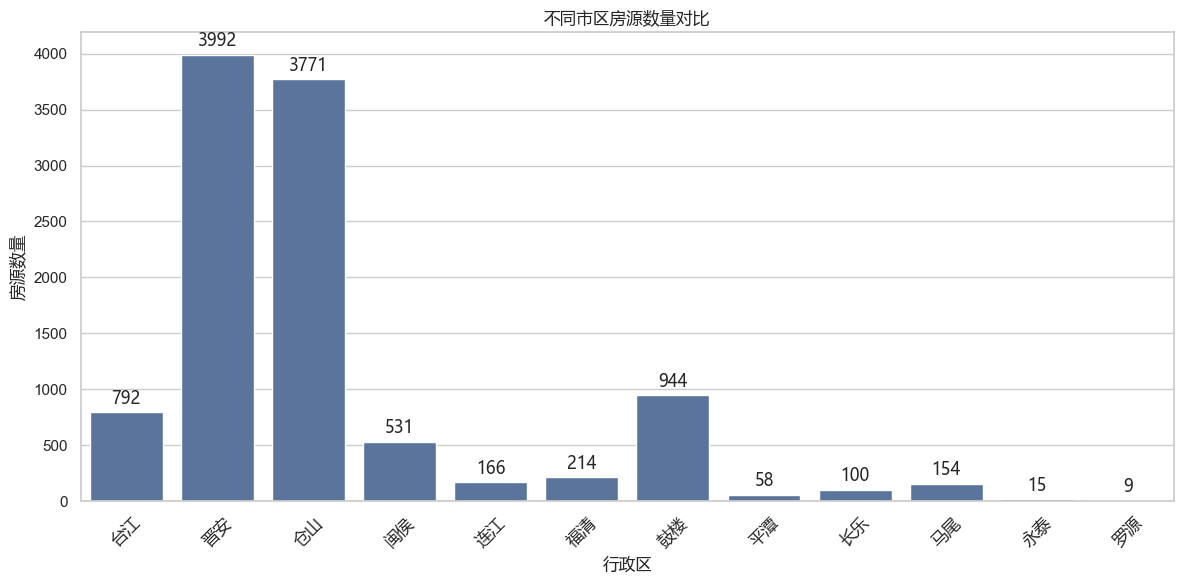

In [42]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=data, x="市区", color="#5072A7")
plt.title("不同市区房源数量对比", fontsize=14, fontproperties=font)
plt.xlabel("行政区", fontsize=12, fontproperties=font)
plt.ylabel("房源数量", fontsize=12, fontproperties=font)

for label in ax.get_xticklabels():
    label.set_fontproperties(font)
plt.xticks(rotation=45)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 40,
        f"{int(height)}",
        ha="center", va="bottom", fontproperties=font
    )

plt.tight_layout()
plt.show()

**分析问题**：对比各行政区二手房挂牌供给规模，识别交易活跃片区
柱状图展示各行政区二手房挂牌总量，柱子上方标注对应房源数量：
1. **晋安、仓山房源数量断层领先**，是二手房交易**核心板块**；
2. 鼓楼、闽侯供给量中等；
3. 罗源、永泰、平潭、长乐等远郊县域房源极少，房产流通**活跃度极低**；
4. 整体二手房市场供给**高度集中主城**，外围县域交易冷清。

### 图表 2：二手房总价分布直方图

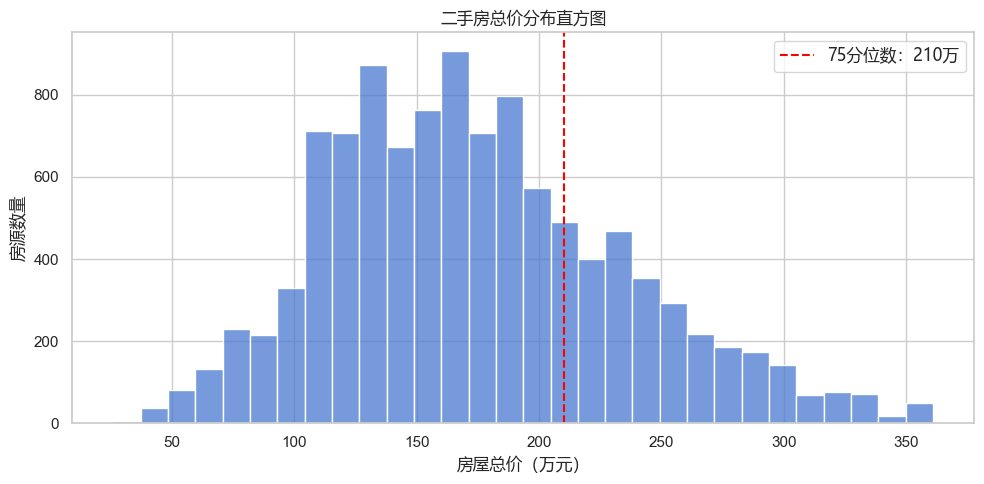

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x="总价提取数字", bins=30, color="#4878CF")

plt.title("二手房总价分布直方图", fontsize=14, fontproperties=font)
plt.xlabel("房屋总价（万元）", fontsize=12, fontproperties=font)
plt.ylabel("房源数量", fontsize=12, fontproperties=font)

plt.axvline(x=210, color="red", linestyle="--", label="75分位数：210万")
plt.legend(prop=font)

plt.tight_layout()
plt.show()

**分析问题**：观察全市二手房总价整体分布，区分刚需、改善房源占比
直方图统计全部房源的总价区间分布，红色虚线为总价75分位数210万元：
1. 房源高度集中在**120万-210万区间**，**刚需住宅**是当前二手房市场主体；
2. 总价超过210万后房源数量快速下滑，**300万以上高端改善房源占比极低**；
3. 整体分布呈轻微右偏特征，少量高价改善房源拉高市场**平均总价**；
4. 市场需求分层清晰，刚需房源供给充足，**高端改善房源稀缺**。

### 图表 3：各户型均价对比箱线图

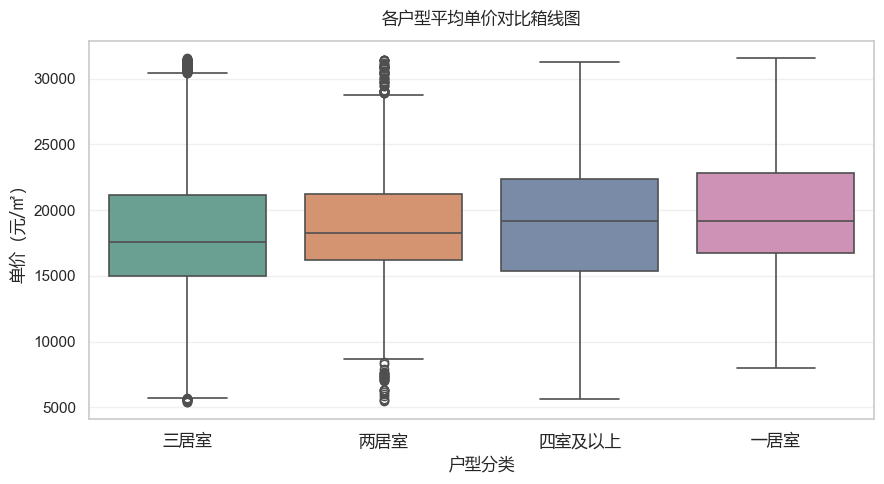

In [36]:
plt.figure(figsize=(9, 5))
palette = ["#60A996", "#E48F62", "#7389AE", "#D888B9"]
ax = sns.boxplot(data=data, x="户型分类", y="均价提取数字", palette=palette, linewidth=1.2)

for patch in ax.artists:
    patch.set_alpha(0.9)

plt.title("各户型平均单价对比箱线图", fontsize=14, fontproperties=font, pad=12)
plt.xlabel("户型分类", fontsize=12, fontproperties=font)
plt.ylabel("单价（元/㎡）", fontsize=12, fontproperties=font)
for label in ax.get_xticklabels():
    label.set_fontproperties(font)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**分析问题**：对比四类户型的单价分布差异，验证小户型学区溢价规律
箱线图展示一居室、两居室、三居室、四室及以上房源单价的中位数、四分位数与极端价格样本分布：
1. **一居室整体单价区间最高**，箱体上下限、中位数均高于其他户型，且顶部存在大量高价离群样本，体现**学区小户型的落户溢价**；
2. 四室及以上改善户型单价整体偏高，价格区间集中，低价极端样本极少，改善房源多位于配套成熟主城区；
3. 两居室单价处于中等水平，高低价离散样本数量最多，新旧小区价差明显；
4. **三居室中位数单价最低**，是**刚需平价主力户型**，市场供给量大、整体购房单价门槛更低。

### 图表 4：房龄与房源单价散点关系图

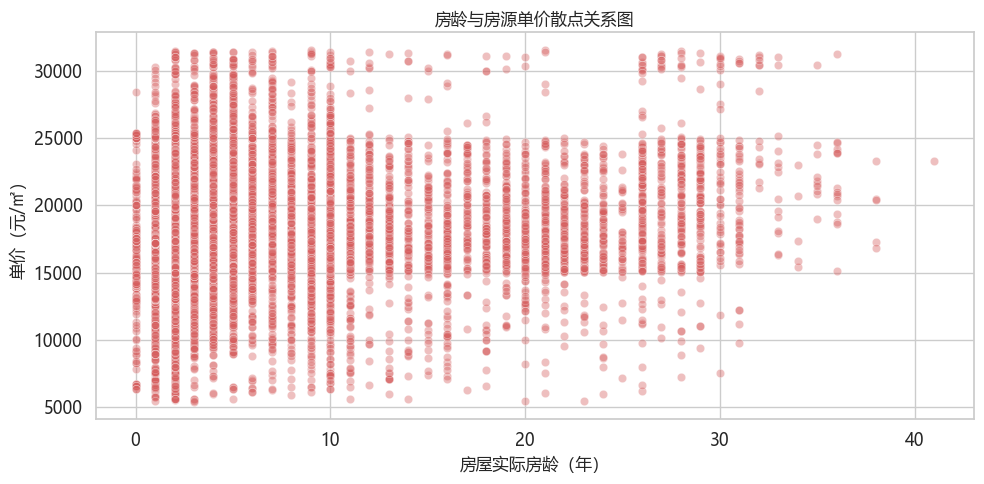

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.scatterplot(data=data, x="实际房龄", y="均价提取数字", alpha=0.4, color="#D65F5F")

plt.title("房龄与房源单价散点关系图", fontsize=14, fontproperties=font)
plt.xlabel("房屋实际房龄（年）", fontsize=12, fontproperties=font)
plt.ylabel("单价（元/㎡）", fontsize=12, fontproperties=font)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

plt.tight_layout()
plt.show()

**分析问题**：探究房屋新旧程度与房源单价的相关关系，对比房龄、地段学区分别对房价的影响力度
横轴为房屋实际房龄，纵轴为房源每平方米单价，每一个红点代表一套二手房房源，点的密集程度代表同条件下房源数量多少：
1. 整体呈现**明显负相关规律**：房龄0-10年的新房、次新房区域高价房源高度密集；随着房龄增大，高单价样本持续减少。
2. 0-10年次新房价格上限可达30000元/㎡以上，新建小区配套、物业、户型设计更具优势，**市场溢价明显**。
3. 房龄超过20年后，整体房价区间明显下沉，极少出现高价房源；仅少量主城核心学区老房能维持较高单价。
4. **同一房龄区间内价格跨度极大**，说明**地段、学区带来的价格差异，远大于房屋房龄造成的价格浮动**，地段是房价核心影响因素。
5. 30年以上老旧房源整体单价偏低，流通价值较弱，**市场认可度不高**。

## 8. 主要结论

### 8.1 五个发现

**福州二手房市场区域分化显著，鼓楼区均价遥遥领先，晋安、仓山为供给主力。**  
- 分组统计显示，鼓楼区均价为 **21560 元/㎡**，居全市首位；台江（19628 元/㎡）、晋安（19374 元/㎡）次之；而永泰均价仅 **7569 元/㎡**，罗源仅 **8043 元/㎡**，不足鼓楼区的一半。图表 1（不同市区房源数量柱状图）进一步表明，晋安（3992 套）和仓山（3771 套）的挂牌量远高于其他区域，是二手房交易的绝对主力板块，而永泰（15 套）、罗源（9 套）几乎无市场流通。两者结合可见，福州二手房市场呈现 **“核心城区价高量多、远郊价低量少”** 的分化格局。

**刚需总价区间高度集中，高端改善房源极为稀缺。**  
- 图表 2（总价分布直方图）显示，房源总价主要集中于 **120 万至 210 万元** 之间，75 分位数为 210 万元；超过 300 万元后，房源数量急剧下降。筛选结果进一步确认，全市总价 ≥ 300 万元的改善型房源仅 **340 套**，且高度集中于晋安（198 套）和仓山（85 套），远郊区域完全没有此类房源。这表明福州二手房市场以 **刚需住宅为主体**，高端改善供给严重不足。

**小户型存在明显的“学区溢价”，三居室为平价刚需主力。**  
- 图表 3（各户型均价箱线图）与户型分组统计显示，一居室虽然平均面积最小（47.8 ㎡），但其平均单价却高达 **19291 元/㎡**，是所有户型中最高的，且箱体上缘和大量离群值均位于高位，体现出小户型因落户、学区需求而产生的单价溢价；相比之下，三居室平均单价仅 **17924 元/㎡**，虽面积更大、总价适中（平均 174.6 万元），但单价门槛最低，是市场上的 **平价刚需主力户型**。四室及以上户型平均总价最高（222.3 万元），但单价（18526 元/㎡）并未明显高于一居室，说明大面积改善房的溢价主要体现在总价而非单价上。

**房龄与房价呈明显负相关，但地段对房价的影响远大于房龄。**  
- 图表 4（房龄与单价散点图）直观显示，0–10 年次新房的高价样本密集，单价上限可达 30000 元/㎡以上；房龄超过 20 年后，高价样本显著减少，整体价格区间下沉。但图中同时可见，**同一房龄区间内价格跨度极大**（例如 5 年房龄的房源单价从 15000 元/㎡到 30000 元/㎡不等），说明房屋新旧程度虽然影响价格，但地段、学区等区位因素造成的价格差异更为显著。交叉表统计也表明，3–5 年次新房挂牌量（3107 套）最大，是市场流通主力，而房龄 10 年以上老房源中，一居室、两居室占比更高，流通价值相对较弱。

**次新房供给以改善型大户型为主，老小区以中小刚需户型为主，市场产品结构随房龄明显分化。**  
- 户型与房龄交叉表显示，新建 0–2 年新房中，三居室（1173 套）和四室及以上（635 套）合计占比超过 80%，说明近年新建楼盘更倾向于供应改善型大户型；而 10 年以上老房中，两居室（430 套）和一居室（20 套）的占比显著提高，反映出早期楼盘以中小户型为主的开发特征。三居室在所有房龄段均排名第一，始终是市场最核心的户型需求。


### 8.2 数据局限与结论谨慎性说明

1. **数据来源为挂牌数据，非实际成交数据。**  
   本报告分析的房源均来自中介平台挂牌信息，挂牌价通常高于最终成交价，且部分房源可能长期未售出或已下架但未及时更新。因此，报告中关于“价格水平”的分析反映的是 **卖方预期价格**，而非真实交易价格，实际市场成交价可能偏低。

2. **部分区域样本量过小，统计结论代表性有限。**  
   罗源（仅 9 套）、永泰（15 套）、平潭（58 套）等远郊区域的房源数量极少，其计算的均价、总价均值受个别极端值影响较大，不能准确代表该区域的整体市场水平。相关区域的价格排名和对比结论需要谨慎引用。

3. **数据清洗中剔除了 IQR 异常值，可能遗漏部分合理高价或低价房源。**  
   为消除极端值对均值和回归分析的干扰，本报告采用四分位距法剔除了面积、总价、均价三方面超出 1.5 倍 IQR 的样本（最终剔除约 1084 条记录）。这一处理虽然提高了主流市场分析的准确性，但也可能排除了部分真实存在的特殊房源（如顶级豪宅、极小户型学区房、老旧特价房等），使得市场极值信息有所损失。

4. **户型字段的“卧室数量”正则提取失败，改为使用人工分类。**  
   由于原始户型文本格式中存在“室”字前后有空格（如“3 室 2 厅 2 卫”），正则提取结果为 0，因此本报告使用基于“室”前数字的 `户型分类` 函数进行分组。该分类方式将“四室及以上”合并为一类，无法进一步区分四室、五室等更大户型的差异，可能掩盖了超大户型的价格特征。

5. **数据缺少楼层朝向、装修程度、学区划片等关键变量。**  
   虽然数据包含“方位”“楼层”字段，但缺少具体的学区信息、装修状况、物业费、建成年代精确月份等，而这些因素在实际购房决策中往往对价格有显著影响。因此，本报告得出的“地段和学区是价格核心因素”的结论是基于区域均价差异的间接推断，尚缺乏直接的学区划片数据支撑。